In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Scenario:\
You’ve been contracted by a South African medical aid scheme. They would like to tailor their medical aid costs according to the lifestyles and geographic regions of their customers. 
You are to create a Linear Regression model that provides a sliding scale of charges according to the age, sex, BMI, number of children, smoking habits, and geographical region of the medical aid scheme’s clients. Use this dataset to train your model as a proof of concept.\
(using the [Medical Cost Personal Dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance) on Kaggle).

In [3]:
df = pd.read_csv("OneDrive/Documents/PDD1/Prog for Data Analytics/insurance.csv") # load dataset

In [4]:
df.head() # the first 5 rows of the dataset

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Exploratory Data Analysis

## Basic Information
This will cover the following:
- The dataset's structure using the info() method - this will also tell us if there are any null values
- A statistical summary of the numerical variables in the dataset using the describe() method
- Then there will be a check for duplicates 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Basic information about the structure of the dataset:
- There are 1338 records and 7 columns 
- There are 3 categorical (object) features (sex, smoker, region)
- 2 floats (BMI, charges)
- 2 integers (age, children)
- There are no null values

In [4]:
df.describe() 

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


The mean is greater than the median (9382 < 13270), this suggests that the data is skewed to the right.\
There standard deviation is 12110 (which shows how far from the mean the charges can be). The mean does not actually represent most people's charges well.\
The maximum charges are 63770, which is more than one standard deviation from the mean, so there are large outliers in the data that are. 

In [6]:
# checking for duplicates 
print(f"Duplicates present? {df.duplicated().any()}")
print(f"Number of duplicates: {df.duplicated().sum()}")

Duplicates present? True
Number of duplicates: 1


In [7]:
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


It is not impossible that two people could have the same characteristics so it may not be necessary to remove this duplicate as it likely has minimal affect on the data

## Univariate Analysis
Analysis of the target variable (charges) will be carried by plotting a histogram and box plot to see the distrubution of the data

(GeeksforGeeks, 2022)

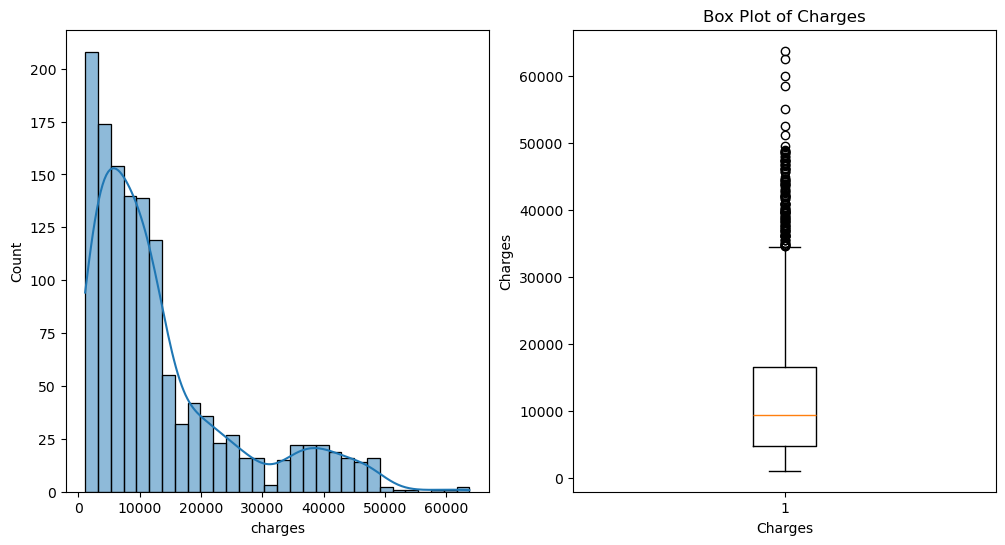

In [8]:
fig, axes = plt.subplots(1, 2, figsize = (12, 6))

#get distribution of target using a histogram (because its continuous data) kbe
sns.histplot(df['charges'], ax = axes[0], kde=True, bins= 30)
plt.title("Distribution of Charges")
plt.xlabel("Charges")

# we want to see if there are outliers
axes[1].boxplot(df['charges'])
axes[1].set_title("Box Plot of Charges")
axes[1].set_ylabel("Charges")

plt.show()

The data histogram shows that the distribution of charges is **skewed to the right**. Most of the insurance charges are on the lower side, and there are very few very high charges. This confirms what was deduced from the [statistical analysis](#Basic-Information) \
Problem -> the data may not be reliable because the mean is biased towards the higher charges, which does not accurately reflect real life

The box plot was used to visualise the outliers (which are represented by the rings)\
Problem -> the model could over rely on these outliers and this would skew the predictions towards the outliers, impacting the model's reliability and accuracy

## Bivariate Analysis
To understand the relationships between the features and the charges (GeeksforGeeks, 2022).\
(categorical data cannot be visualised with a scatterplot so bar graphs were used)

In [6]:
# splitting numerical and categorical features
df_features = df.drop(["charges"], axis=1).columns
df_categorical = ["sex", "smoker", "region"]
df_numerical = ["age", "bmi", "children"]

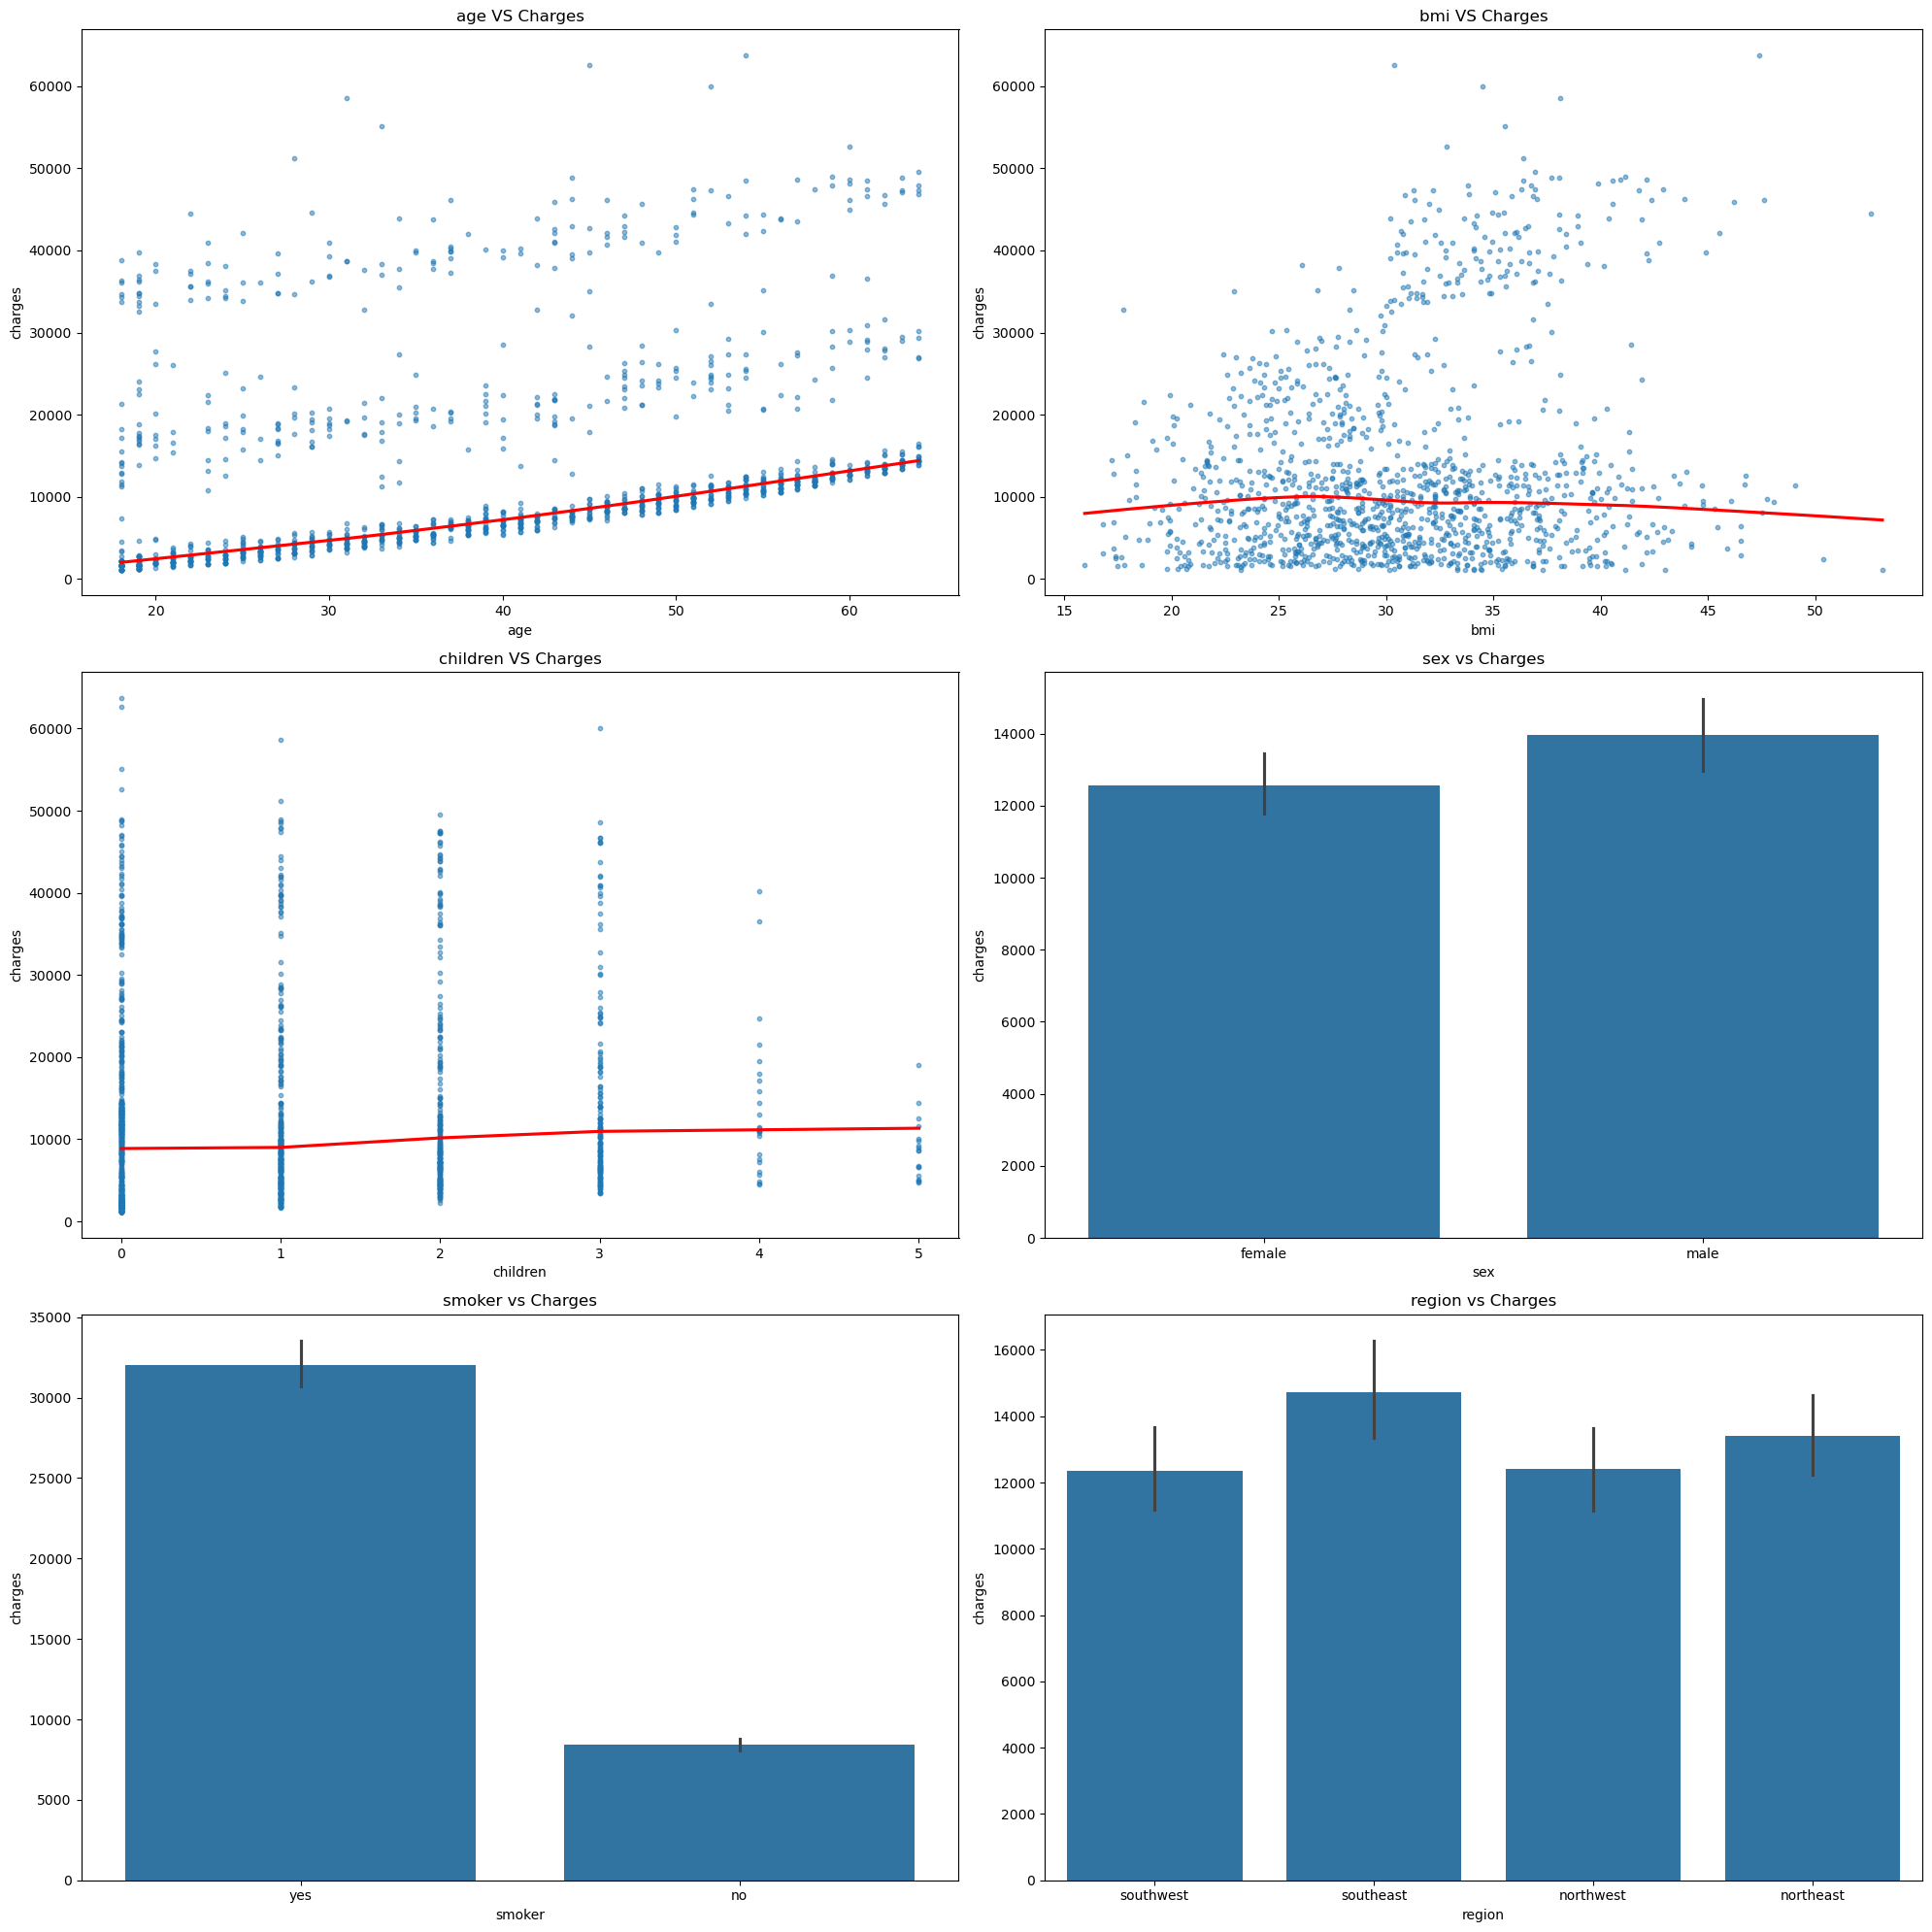

In [7]:
fig, axes = plt.subplots(3,2, figsize = (20,20))
axes = axes.flatten()

# Numerical Data -> scatterplots
for i, feature in enumerate(df_numerical):
    axes[i].scatter(df[feature], df["charges"], alpha=0.5, s=10)
    sns.regplot(x=df[feature], y= df["charges"], ax= axes[i], scatter=False, lowess=True, color='red')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("charges")
    axes[i].set_title(f"{feature} VS Charges")

# Categorical Data -> bar plots
for i, feature in enumerate(df_categorical):
    sns.barplot(x=feature, y="charges", data=df, ax=axes[i + len(df_numerical)])
    axes[i + len(df_numerical)].set_title(f"{feature} vs Charges")
    
plt.tight_layout()
plt.show()

What the scatter plots tell us:
- There is a moderate positive linear relationship between age and charges
- There is no much of a linear relationship between bmi and charges -> the data is widely scattered and the regression line is almost flat
- There is a weak postive relationship between the number of children and charges -> the charges vary quite a bit with each number of children

What the bar graphs tell us:
- Sex has an association with charges -> males tend to have higher charges than women
- Smokers have much higher charges than non-smokers 
- There is not much of a relationship between region and charges

### Encoding
The categorical data (sex, smoker, region) need to be encoded into numerical form so further analysis can be conducted

In [8]:
lb = LabelEncoder()

df["sex"] = lb.fit_transform(df["sex"])
df["smoker"] = lb.fit_transform(df["smoker"])
df["region"] = lb.fit_transform(df["region"])

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


Note:
- Sex -> female = 0 | male = 1
- Smoker -> 0 = no | 1 = yes
- Region -> 0 = northeast | 1 = northwest | 2 = southeast | 3 = southwest

### Correlation
Correlation represents the strength and direction of the relationship between two variables. These values back up the observations in the graphs above

- Smoking has a strong positive correlation with charges and it is the strongest predictor
- The rest of the correlations are rather weak and positive except for region which has a weak negative correlation

In [69]:
df_corr = pd.DataFrame({"Correlation":  df.corr()['charges'].sort_values(ascending=False)})
df_corr

,Correlation
charges,1.000000
charges_log,0.892996
smoker,0.787251
age,0.299008
bmi,0.198341
children,0.067998
sex,0.057292
region,-0.006208


## Multivariate Analysis
Analysis of feature-feature relationship to see if there is any multicollinearity in the dataset. One of the assumptions of linear regression is that none of the features are highly correlated with one another.\
A heatmap was used to visualise the correlations between features.

(GeeksforGeeks, 2022)

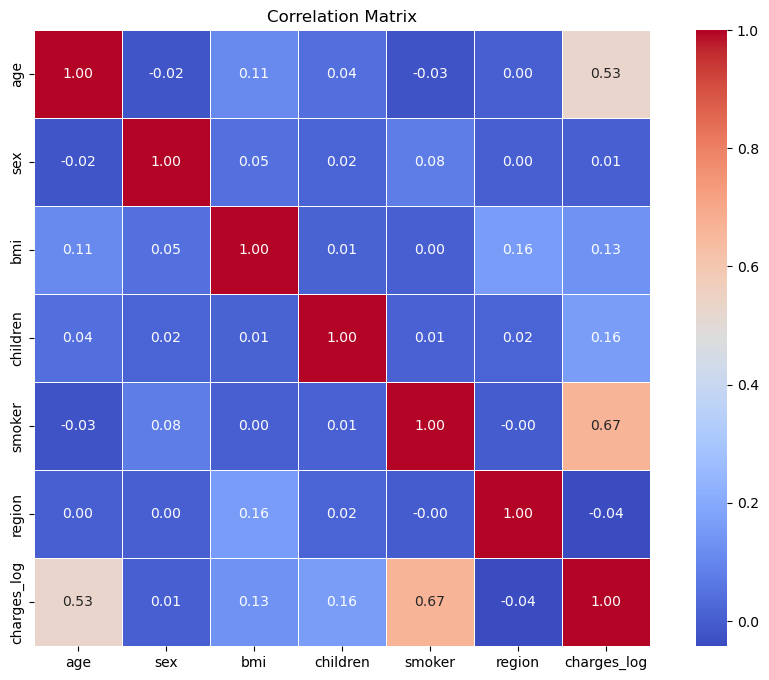

In [71]:
df_corr = df.drop("charges", axis =1)
plt.figure(figsize=(12,8))
sns.heatmap(df_corr.corr(), annot = True, fmt = '.2f', cmap='coolwarm', square=True, linewidth=0.5)
plt.title("Correlation Matrix")
plt.show()

None of the features in the dataset are highly correlated, so this assumption has been satisfied

## More Preprocessing

### Log Transformation
Now that analysis has been done, more preprocessing steps can be taken to prepare the data for the model.

The outliers shown during the [univariate analysis](#Univariate-Analysis) must be dealt with so the model does not work with skewed information, however, they cannot simply be removed since they are still a valid charges and are not likely to be errouneous.\
To address the skewness and outliers in the data, **Log Transformation** was applied to the charges to achieve a normal distribution

In [17]:
df["charges_log"] = np.log1p(df["charges"])
df.head() # dataset with log transformed charges added

,age,sex,bmi,children,smoker,region,charges,charges_log
0,19,0,27.900,0,1,3,16884.92400,9.734236
1,18,1,33.770,1,0,2,1725.55230,7.453882
2,28,1,33.000,3,0,2,4449.46200,8.400763
3,33,1,22.705,0,0,1,21984.47061,9.998137
4,32,1,28.880,0,0,1,3866.85520,8.260455


The replotted box plot shows there are no longer any outliers and the histogram shows the data is now more normally distributed than before.\
The bivariate analysis will be visualised again to show how the data distribution has changed

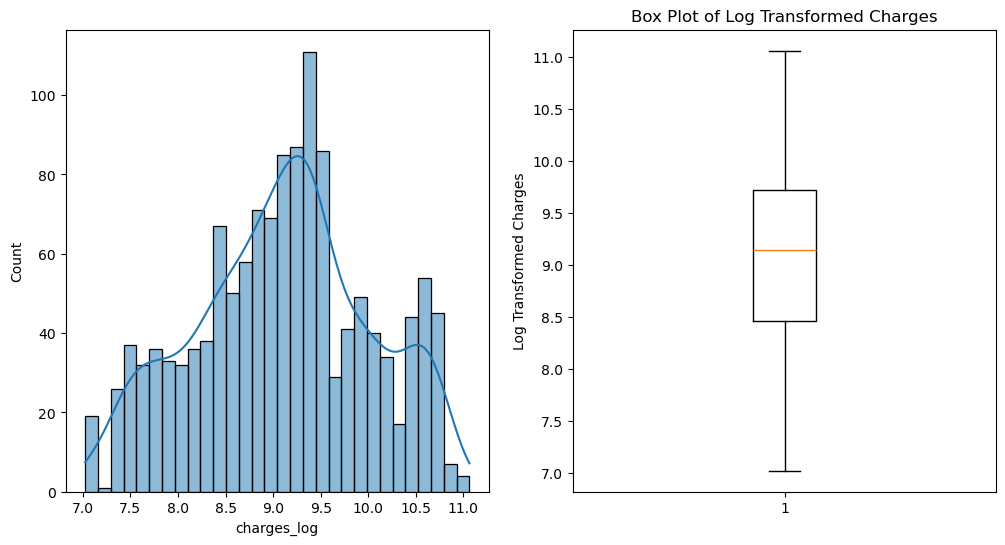

In [24]:
fig, axes = plt.subplots(1, 2, figsize = (12, 6))

#get distribution of target using a histogram (because its continuous data) kbe
sns.histplot(df['charges_log'], ax = axes[0], kde=True, bins= 30)

# we want to see if there are outliers
axes[1].boxplot(df['charges_log'])
axes[1].set_title("Box Plot of Log Transformed Charges")
axes[1].set_ylabel("Log Transformed Charges")

plt.show()

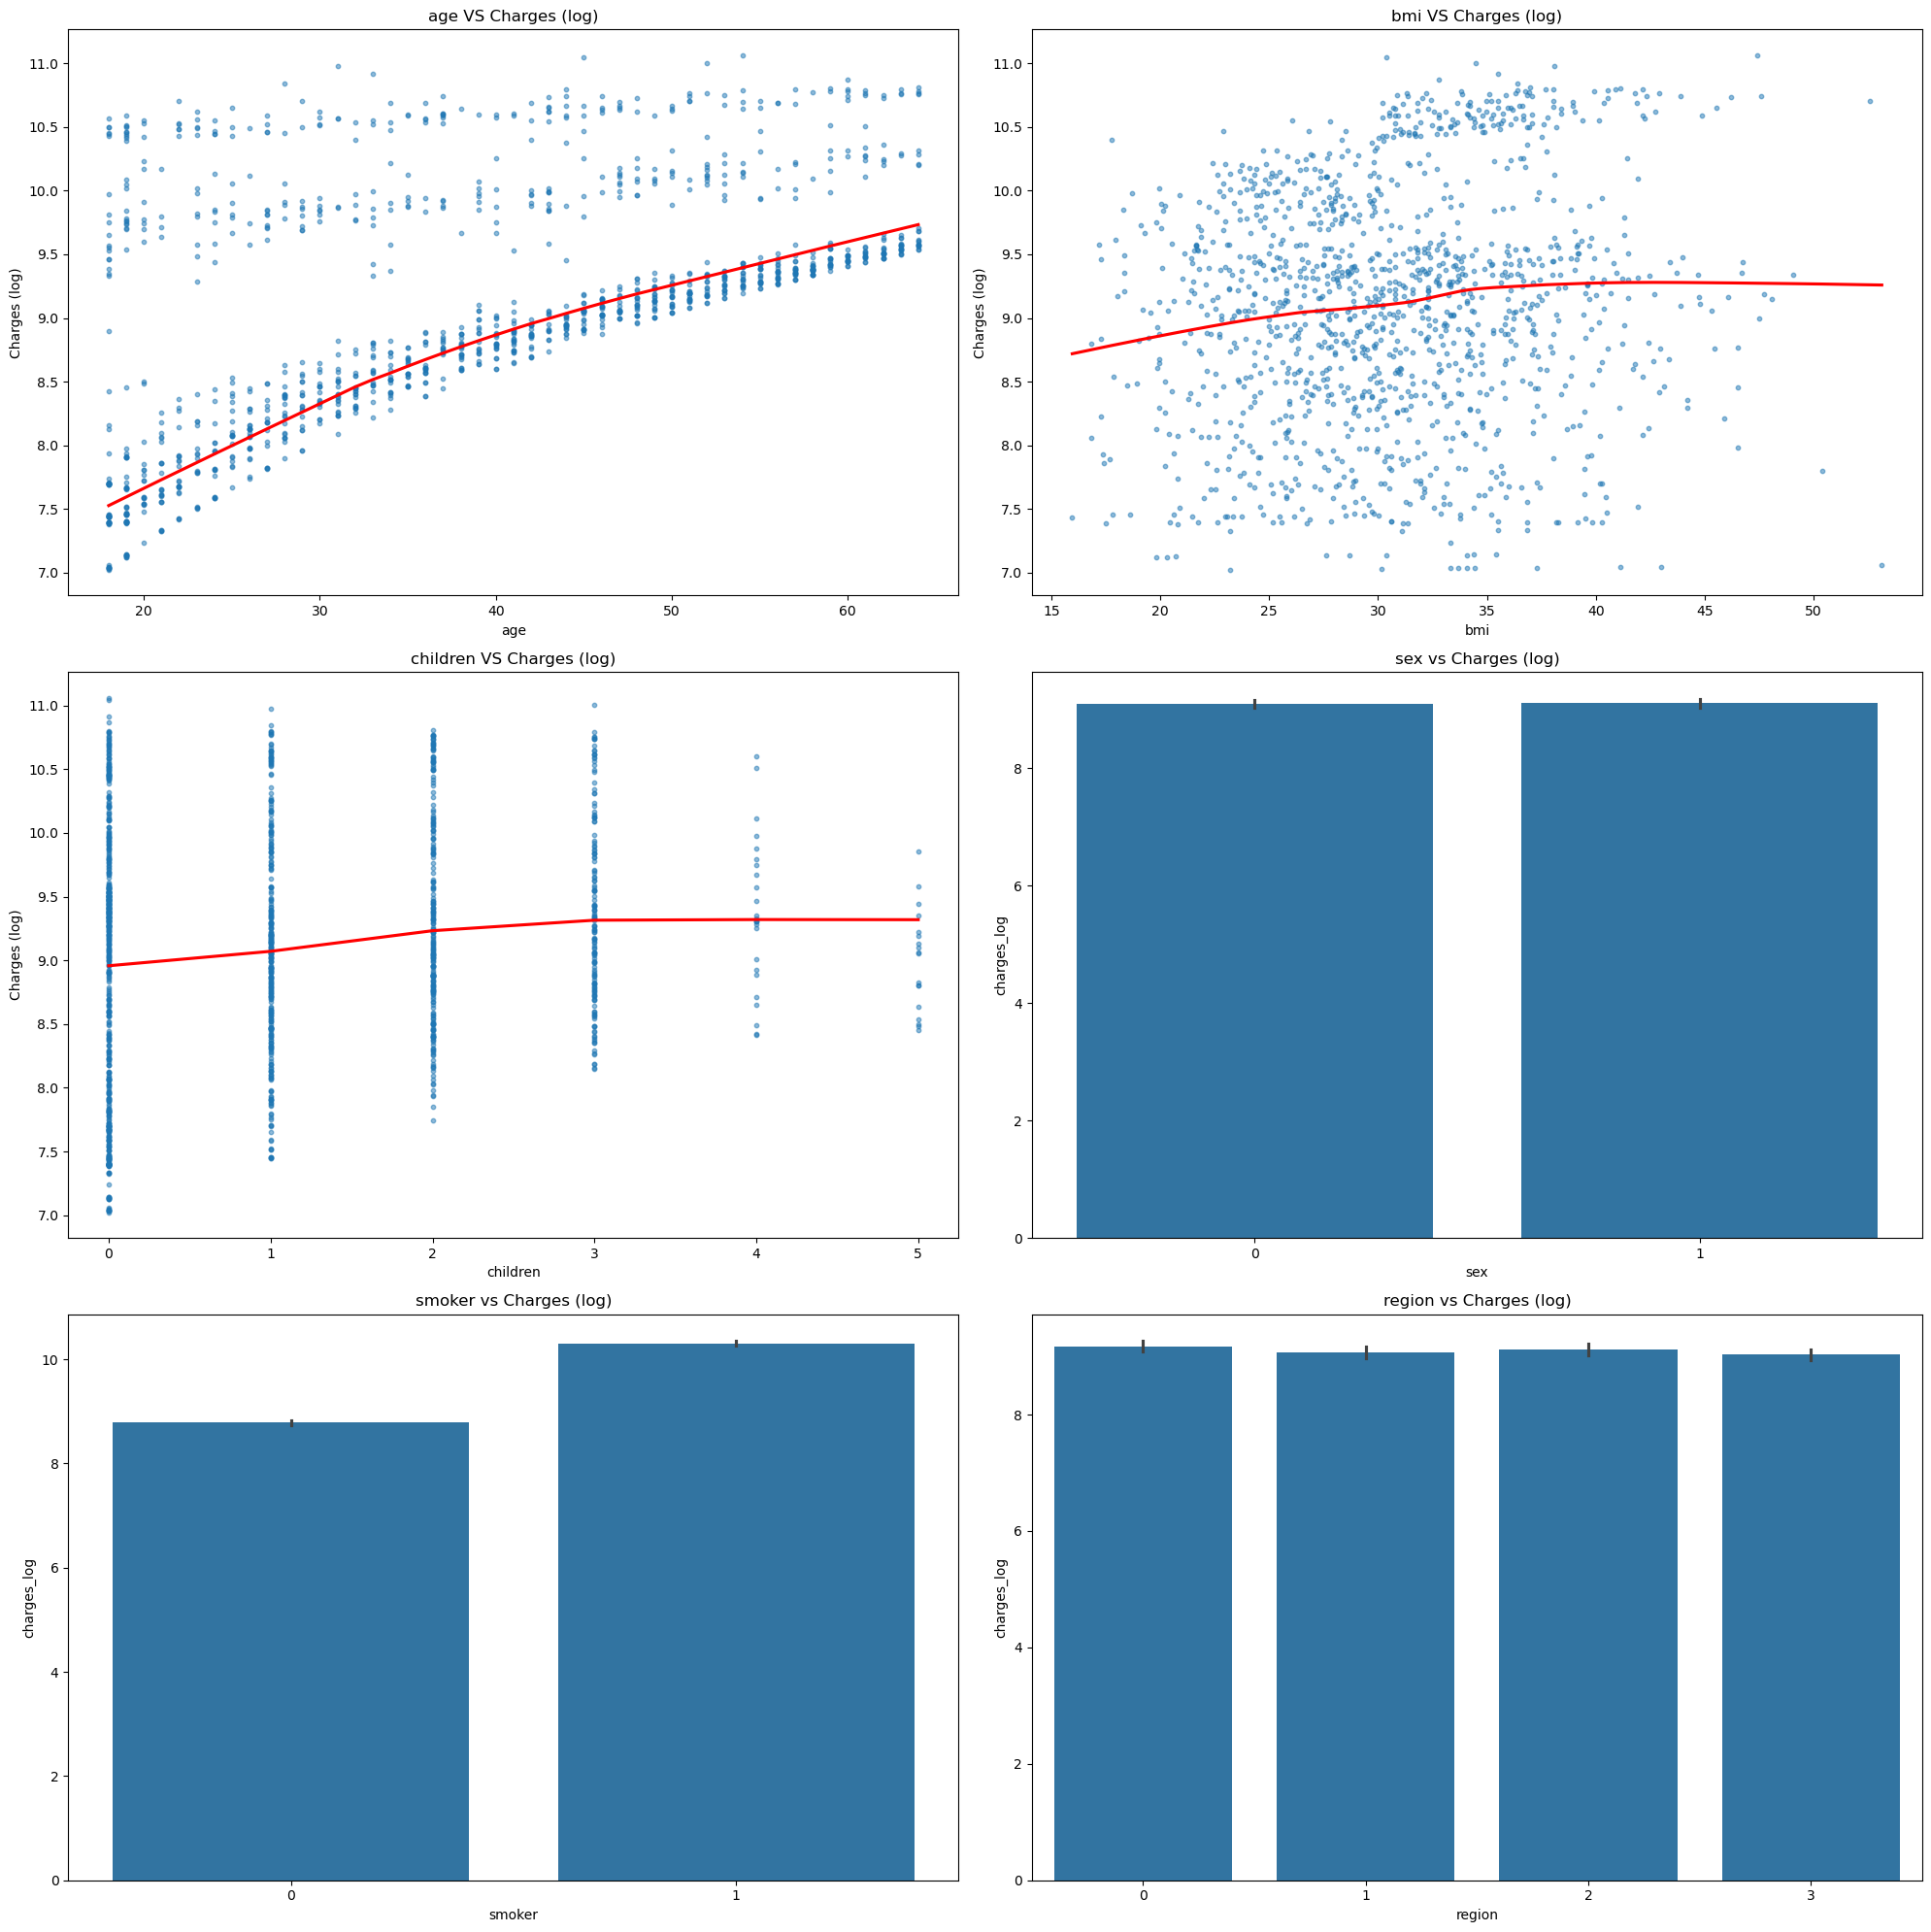

In [25]:
fig, axes = plt.subplots(3,2, figsize = (20,20))
axes = axes.flatten()

# Numerical Data -> scatterplots
for i, feature in enumerate(df_numerical):
    axes[i].scatter(df[feature], df["charges_log"], alpha=0.5, s=10)
    sns.regplot(x = df[feature], y = df["charges_log"], ax = axes[i], scatter=False, lowess=True, color='red')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Charges (log)")
    axes[i].set_title(f"{feature} VS Charges (log)")

# Categorical Data -> bar plots
for i, feature in enumerate(df_categorical):
    sns.barplot(x = feature, y ="charges_log", data = df, ax = axes[i + len(df_numerical)])
    axes[i + len(df_numerical)].set_title(f"{feature} vs Charges (log)")
    
plt.tight_layout()
plt.show()

# Feature Selection
Firstly, the correlation analysis done in the bivariate analysis section could inform feature selection by filtering out those that have very weak correlations with the target variable. However, there are only 6 features and it may not be necessary to discard them -> it could reduce model performance 
Other than this, the relevance of each feature weas determined based on its p-value. Features with a p value lower than 0.05 are considered statistically significant (Bobbitt, 2022). If any were to have a p-value higher than 0.05, they could probably be discarded.

In [26]:
df1 = df.drop("charges", axis = 1)
df1.columns # just to confirm which variables are present

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges_log'], dtype='object')

In [27]:
# split data into features and label since i will use x in getting the p value
x = df1.drop("charges_log", axis=1)
y = df1["charges_log"]

## Statistical Significance - p value
The p value is calculated and only features with p values less than 0.05 will be shown

In [28]:
# (Bobbitt, 2022)
sm_x = sm.add_constant(x)
temp_model = sm.OLS(y, sm_x).fit()
pvalues = temp_model.pvalues.drop("const").round(5) # Get p value 

feature_sig = pd.DataFrame({"Feature": x.columns, "PValue": pvalues.values})

# get statistically significant features only 
feature_sig = feature_sig[feature_sig["PValue"] < 0.05]
feature_sig.sort_values(by = "PValue", ascending = False).reset_index(drop=True)

,Feature,PValue
0,sex,0.00209
1,region,0.00002
2,age,0.00000
3,bmi,0.00000
4,children,0.00000
5,smoker,0.00000


All the features are statistically significant, so all of them will be used to train the model. 

# Model Training

- The model will be trained with all the features of the dataset (with the log transformed charges)
- x and y were already defined [above](#Feature-Selection) 
- The data is split with 80% for training and 20% for testing
- Then feature scaling will be done (using StandardScalar) to ensure all features are on the same scale and none dominate over others -> all features can be considered equally

### Splitting & Scaling 

In [29]:
# x (features) and y (charges) were already defined above, so next is the split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [30]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [32]:
model = LinearRegression() # init model

## Hyperparameter Tuning
Before training the model, hyperparameter tuning will be done to select the best hyperparameters for this model in order to achieve the best results. This will be done using the **Random Search** method.

(GeeksforGeeks, 2024)

In [33]:
model.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

In [34]:
param_space = {'copy_X': [True,False], 
               'fit_intercept': [True,False], 
               'n_jobs': [1,5,10,15,None], 
               'positive': [True,False]}

In [35]:
# (GeeksforGeeks, 2024)
random_search = RandomizedSearchCV(model, param_space, n_iter=100, cv=5)
random_search.fit(x_train, y_train)

C:\Users\tshia\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 40 is smaller than n_iter=100. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,estimator,LinearRegression()
,param_distributions,"{'copy_X': [True, False], 'fit_intercept': [True, False], 'n_jobs': [1, 5, ...], 'positive': [True, False]}"
,n_iter,100
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [36]:
print(f"- The Best Hyperparameters: {random_search.best_params_}")
print(f"- Best Score: {random_search.best_score_}")# this shows the accuracy of the model using the best parameters

- The Best Hyperparameters: {'positive': False, 'n_jobs': 1, 'fit_intercept': True, 'copy_X': True}
- Best Score: 0.7520088185241253


## Predictions
Predictions can be made with the tuned model\
The predictions are tabulated in log form and as the original values

In [37]:
best_model = random_search.best_estimator_ # (GeeksforGeeks, 2024)

In [38]:
y_pred = best_model.predict(x_test)

In [41]:
results = pd.DataFrame({"Predicted": np.exp(y_pred), "Actual": np.exp(y_test), 
                        "Predicted (log)": y_pred, "Actual (log)": y_test
                       }).reset_index(drop=True)
results.head()

,Predicted,Actual,Predicted (log),Actual (log)
0,9017.545445,9096.06825,9.106927,9.115598
1,5601.441616,5273.17580,8.630779,8.570388
2,66156.133109,29331.98315,11.099773,10.286434
3,9162.422200,9302.89355,9.122866,9.138081
4,14002.975496,33751.29180,9.547025,10.426774


# Model Evaluation
The model performance will be evaluated using MAE, MSE, RMSE, and R Squared because they give insight into the model's accuracy and how well it fits. MAE measures the average size of errors in an interpretable way. MSE and RMSE heavily penalise large errors which would be relevant in the context of insurance charges. RMSE is more interpretable since it keeps gives a value in the original units. R Squared shows how well the model can explain the variability in charges.
All four of these metrics will give a good assessment of the models accuracy and reliability.

After this, residual diagnostics were done (using graphs) to get a clearer picture of how the model interacts with the data 

## Evaluation Metrics
The charges were log-transformed to reduce skewness and improve model performance, so evaluation was done on the log transformed values and also converted back to the original scale to show what the error is in terms of money just for comparison and interpretability

In [42]:
mae = mean_absolute_error(y_test, y_pred)
print(f"- Mean Absolute Error: {mae}")
mse = mean_squared_error(y_test, y_pred)
print(f"- Mean Squared Error: {mse}")
rmse = np.sqrt(mse)
print(f"- Root Means Squared Error: {rmse}")
r2 = r2_score(y_test, y_pred)
print(f"- R Squared: {r2}")

- Mean Absolute Error: 0.27077904040663553
- Mean Squared Error: 0.17749634350463936
- Root Means Squared Error: 0.42130314917484224
- R Squared: 0.8025302232167126


**Model Performance on Log Transformed Charges:**
The model has fairly strong performance with an R Squared value of 0.8025 which indicates that about 80% of the variance in the insurance charges is explained by the model. The low MAE score of 0.271, MSE of 0.177, and RSME of 0.421 show that the prediction errors are small.

Overall, the metrics suggest that the model is effective for predicting medical insurance charges although some of the variability (about 20%) is unexplained, this shows that there is room for improvement.

(GeeksforGeeks, 2023)

In [43]:
#reversed log transformation
og_mae = mean_absolute_error(np.exp(y_test), np.exp(y_pred))
print(f"- Mean Absolute Error: {og_mae}") 
og_mse = mean_squared_error(np.exp(y_test), np.exp(y_pred))
print(f"- Mean Squared Error: {og_mse}")
og_rmse = np.sqrt(og_mse)
print(f"- Root Means Squared Error: {og_rmse}")
og_r2 = r2_score(np.exp(y_test), np.exp(y_pred))
print(f"- R Squared: {og_r2}")

- Mean Absolute Error: 3909.1358713262252
- Mean Squared Error: 61639120.5380065
- Root Means Squared Error: 7851.058561621261
- R Squared: 0.6029653837057426


**Model Performance Metrics on Original Scale**:
This paints a different picture of the model's performance. The model has moderate performance, with an R squared value of 0.603 which indicates that about 60% of the variance in the charges is explained by the model. 

The average prediction error is about R3909 (based on MAE) and larger charges can reach an average error of about R7855 (based on RMSE). This means the model is not precise enough

(GeeksforGeeks, 2023)

## Residual Diagnostics
Analysis of residuals was done to validate the assumptions of linear regression and see whether the model is appropriate for the data
The assumptions are:
1. **Linear relationship** between features and target by assessing residuals vs predictions
3. **Homoscedasticity**: variance residuals should be constantl
4. **Normally Distributed Errors**: Residuals follow a normal distribution

In [44]:
residuals = y_test - y_pred

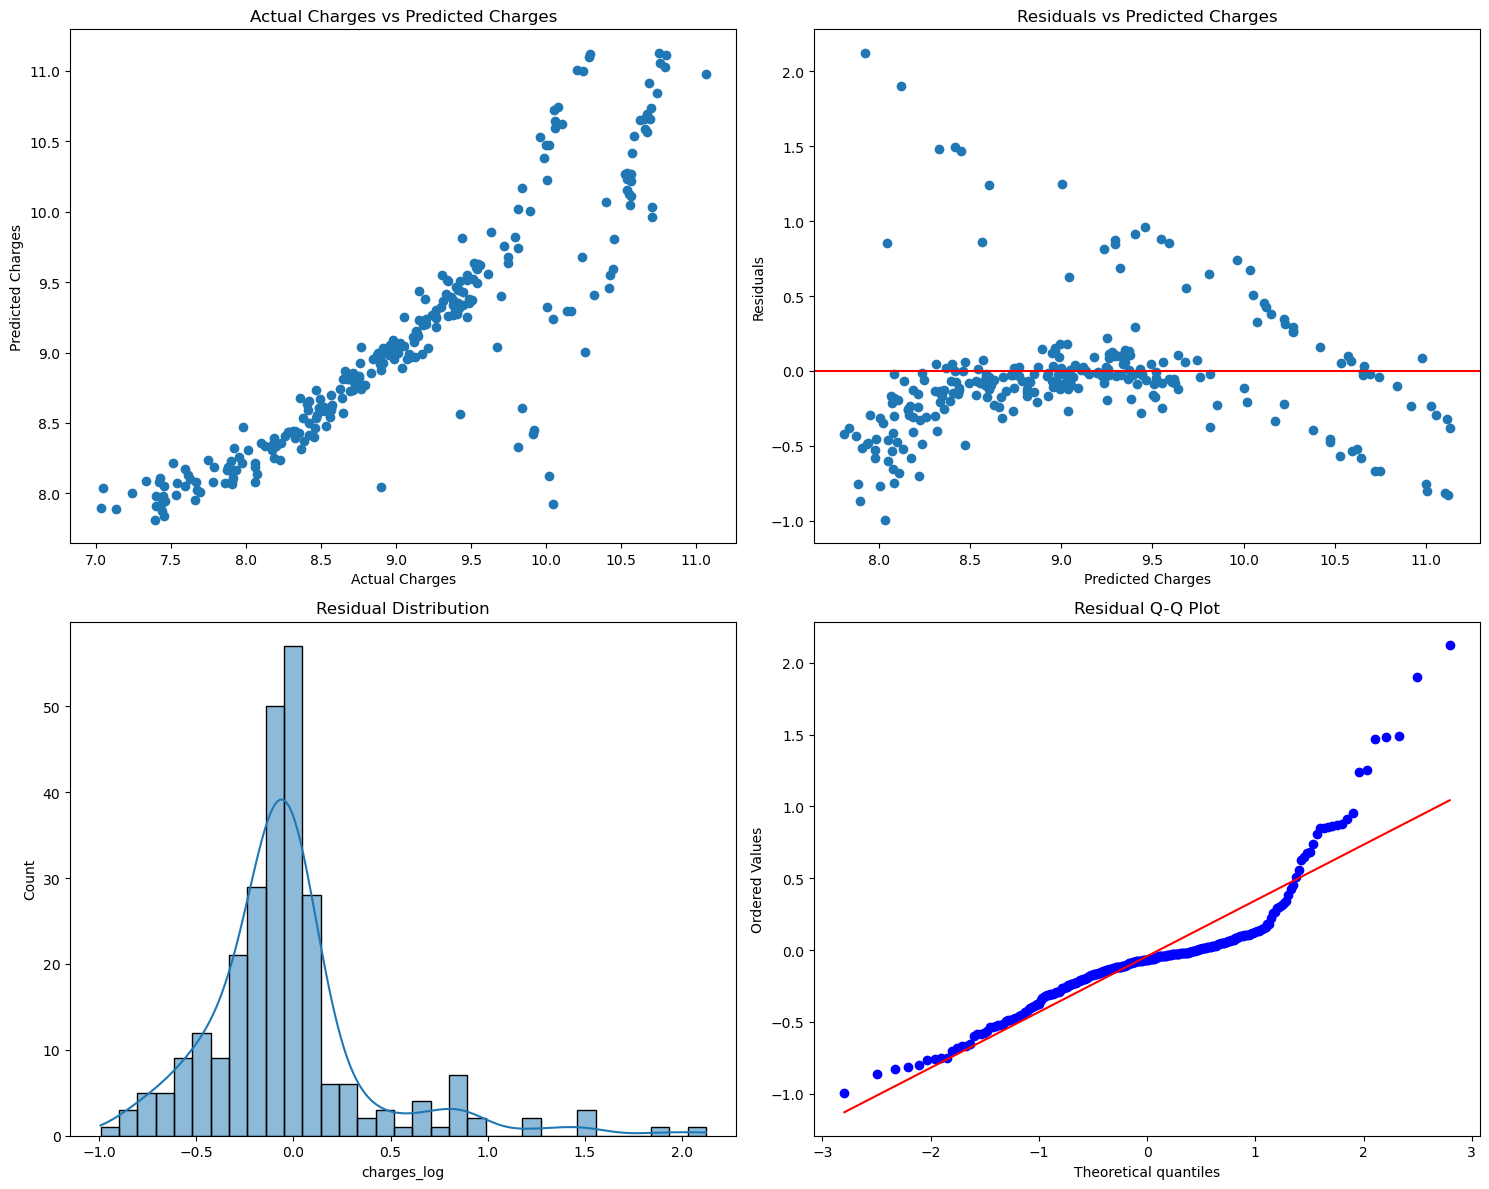

In [45]:
fig, axes = plt.subplots(2,2, figsize = (15,12))

axes[0,0].scatter(y_test, y_pred)
axes[0,0].set_xlabel("Actual Charges")
axes[0,0].set_ylabel("Predicted Charges")
axes[0,0].set_title("Actual Charges vs Predicted Charges")

axes[0,1].scatter(y_pred, residuals)
axes[0,1].axhline(0, color = 'red')
axes[0,1].set_xlabel("Predicted Charges")
axes[0,1].set_ylabel("Residuals")
axes[0,1].set_title("Residuals vs Predicted Charges")

sns.histplot(residuals, kde=True, ax = axes[1,0])
axes[1,0].set_title("Residual Distribution")

#visually assess whether the residuals from a regression model follow a normal distribution
stats.probplot(residuals, dist='norm', plot = axes[1, 1])
axes[1,1].set_title("Residual Q-Q Plot")

plt.tight_layout()
plt.show()

The expectation for actual vs predicted charges is for the points to follow a straight diagonal line. Unfortunately, it is curved -> the model is missing non-linear relationships 

The expectation for residuals vs predicted charges is for the points to be randomly scattered around the zero point with no clear model. However, the plot is curved downward, meaning the relationships is not linear and the model is missing something. This has violated the assumption of homoscedasticity\
Transformation is usually suggested to correct this problem, but it was already done and the desired result was not achieved (Lakhloufi, 2026a).

The purpose of the histogram is to see if the residuals are normally distributed. The expectation is a symmetrical bell curve around the zero point. This plot is skewed, so the errors are not normally distributed and the assumption of noramally distributed errors has not been satisfied (Lakhloufi, 2026a). \
The Q-Q plot corroborates the violation of the assumption of normally distributed charges since the points deviate from the line significantly as values get higher (Lakhloufi, 2026b).

# Model Improvements & Retraining
The model's performance was good, however it is struggling to capture non-linearity and it seems there are still influences from outliers considering the skewness\
The following methods were employed to attempt to improve the model's performance:
1. Regularisation techniques by using methods like Lasso, Ridge and Elastic Net to apply penalities to correlation coefficients and reduce irrelevant features
2. Adding polynomial features to help with non-linear features

## Lasso Regression
This method performs feature selection by shrinking coefficients to zero, this will let us know if removing irrelevant features improves model performance

In [47]:
lasso = Lasso(alpha=0.01) # penality value (1 is most common)
lasso.fit(x_train, y_train)

y_pred_lasso = lasso.predict(x_test)

In [48]:
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
print(f"- Mean Average Error: {mae_lasso}")
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
print(f"- Mean Squared Error: {mse_lasso}")
rmse_lasso = np.sqrt(mse_lasso)
print(f"- Root Mean Squared Error: {rmse_lasso}")
r2_lasso = r2_score(y_test, y_pred_lasso)
print(f"- R Squared: {r2_lasso}")

- Mean Average Error: 0.27220921410343524
- Mean Squared Error: 0.17987130037795812
- Root Mean Squared Error: 0.4241123676314546
- R Squared: 0.7998880155273361


## Ridge Regression
This method will shrink the coefficients, but not to zero -> it does not perform feature selection

In [49]:
ridge = Ridge(alpha=1.0) 
ridge.fit(x_train, y_train)

y_pred_ridge = ridge.predict(x_test)

In [50]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
print(f"- Mean Average Error: {mae_ridge}")
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
print(f"- Mean Squared Error: {mse_ridge}")
rmse_ridge = np.sqrt(mse_ridge)
print(f"- Root Means Squared Error: {rmse_ridge}")
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"- R Squared: {r2_ridge}")

- Mean Average Error: 0.2709467322768964
- Mean Squared Error: 0.1775325346652569
- Root Means Squared Error: 0.4213460984336474
- R Squared: 0.8024899595117396


## Elastic Net
Elastic Net Regression is a combination of L1 and L2 regularisation techniques

In [51]:
elastic = ElasticNet(alpha=0.01, l1_ratio=0.5) #l1 ratio is the balance between L1 and L2 penality that will be applied here
elastic.fit(x_train, y_train)

y_pred_elastic = elastic.predict(x_test)

In [52]:
mae_elastic = mean_absolute_error(y_test, y_pred_elastic)
print(f"- Mean Average Error: {mae_elastic}")
mse_elastic = mean_squared_error(y_test, y_pred_elastic)
print(f"- Mean Squared Error: {mse_elastic}")
rmse_elastic = np.sqrt(mse_elastic)
print(f"- Root Means Squared Error: {rmse_elastic}")
r2_elastic = r2_score(y_test, y_pred_elastic)
print(f"- R Squared: {r2_elastic}")

- Mean Average Error: 0.2723629511418834
- Mean Squared Error: 0.1788025460445524
- Root Means Squared Error: 0.4228505008209786
- R Squared: 0.8010770353994456


## Conclusions on Regularisation:
The MAE, MSE and RMSE values are very similar across all the models. The original model's R2 score is still the highest. Overall, regularisation did not aid in improving model performance.

All the scores achieved are tabulated below for comparison

In [54]:
df_comparison = pd.DataFrame({
    "MAE": [mae, mae_lasso, mae_ridge, mae_elastic],
    "MSE": [mse, mse_lasso, mse_ridge, mse_elastic],
    "RMSE": [rmse, rmse_lasso, rmse_ridge, rmse_elastic],
    "R2": [r2, r2_lasso, r2_ridge, r2_elastic] 
}, index=["Original", "Lasso", "Ridge", "Elastic Net"])
df_comparison.sort_values(by = "R2", ascending= False)

,MAE,MSE,RMSE,R2
Original,0.270779,0.177496,0.421303,0.802530
Ridge,0.270947,0.177533,0.421346,0.802490
Elastic Net,0.272363,0.178803,0.422851,0.801077
Lasso,0.272209,0.179871,0.424112,0.799888


## Ploynomial Features
Polynomial features introduce non-linear relationships which should improve the model’s performance (Mazraeh, 2025). Non-linearity seems to be the biggest problem in using the Linear Regresssion model

In [55]:
# (Mazraeh, 2025)
poly = PolynomialFeatures(degree=3)
x_train_poly = poly.fit_transform(x_train)

poly_model2 = LinearRegression()
poly_model2.fit(x_train_poly, y_train)

x_test_poly = poly.transform(x_test)

In [56]:
y_pred_poly = poly_model2.predict(x_test_poly)

In [65]:
mae_poly = mean_absolute_error(y_test, y_pred_poly)
print(f"- Mean Absolute Error: {mae_poly}")
mse_poly = mean_squared_error(y_test, y_pred_poly)
print(f"- Mean Squared Error: {mse_poly}")
rmse_poly = np.sqrt(mse_poly)
print(f"- Root Means Squared Error: {rmse_poly}")
r2_poly = r2_score(y_test, y_pred_poly)
print(f"- R Squared: {r2_poly}")

- Mean Absolute Error: 0.2008857436325712
- Mean Squared Error: 0.12576347794091608
- Root Means Squared Error: 0.35463146778157756
- R Squared: 0.8600845210322123


This improved the model performance, the R Squared value is 0.8601 -> the model can explain 86% of the variance as opposed to the 80% the original model could. It has the lowest MAE, MSE, and RMSE so the prediction errors are smaller. 

Below are the metrics on the original scale to show the error in monetary terms\
It can be noted that this time, the R Squared value still shows the model can explain 86% of target variability (unlike what was observed when coverting the original models scores). The errors are still smaller than the orginal model's

In [64]:
mae_poly_og = mean_absolute_error(np.exp(y_test), np.exp(y_pred_poly))
print(f"- Mean Absolute Error: {mae_poly_og}")
mse_poly_og = mean_squared_error(np.exp(y_test), np.exp(y_pred_poly))
print(f"- Mean Squared Error: {mse_poly_og}")
rmse_poly_og = np.sqrt(mse_poly)
print(f"- Root Means Squared Error: {rmse_poly_og}")
r2_poly_og = r2_score(np.exp(y_test), np.exp(y_pred_poly))
print(f"- R Squared: {r2_poly_og}")

- Mean Absolute Error: 2348.2549842932704
- Mean Squared Error: 21350572.941826165
- Root Means Squared Error: 4620.668019001816
- R Squared: 0.8624750570476802


In [60]:
poly_residuals = y_test - y_pred_poly

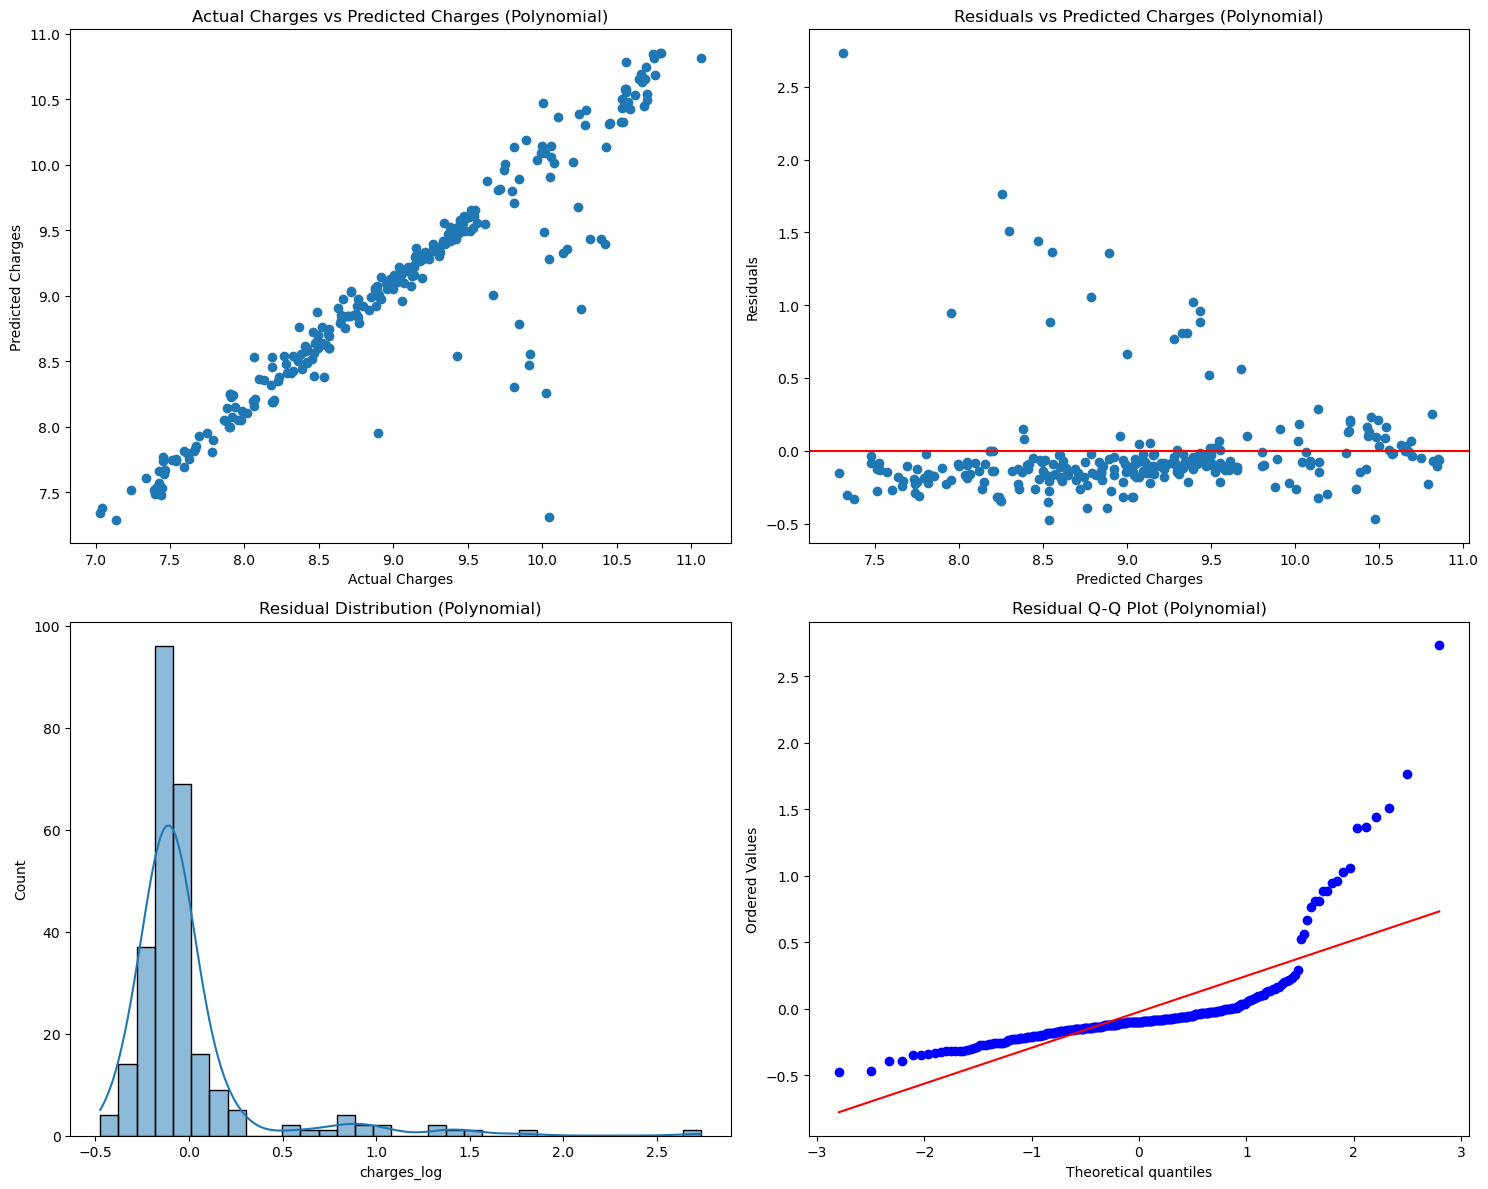

In [70]:
fig, axes = plt.subplots(2,2, figsize = (15,12))

axes[0,0].scatter(y_test, y_pred_poly)
axes[0,0].set_xlabel("Actual Charges")
axes[0,0].set_ylabel("Predicted Charges")
axes[0,0].set_title("Actual Charges vs Predicted Charges (Polynomial)")

axes[0,1].scatter(y_pred_poly, poly_residuals)
axes[0,1].axhline(0, color = 'red')
axes[0,1].set_xlabel("Predicted Charges")
axes[0,1].set_ylabel("Residuals")
axes[0,1].set_title("Residuals vs Predicted Charges (Polynomial)")

sns.histplot(poly_residuals, kde=True, ax = axes[1,0])
axes[1,0].set_title("Residual Distribution (Polynomial)")

#visually assess whether the residuals from a regression model follow a normal distribution
stats.probplot(poly_residuals, dist='norm', plot = axes[1, 1])
axes[1,1].set_title("Residual Q-Q Plot (Polynomial)")

plt.tight_layout()
plt.show()

The actual vs predicted charges plot shows a strong linear relationship, so the model seems to capture the general trend. However, towards the top, the data points widen a bit, confirming that predictions for higher charges are more erroneous. The assumption of independence of errors has not been completely satisfied.

The plot of residual vs predicted charges shows that the assumption of homoscedasticity is not satisfied since the residuals are not randomly scattered.

The residuals are not normally distributed either, they are skewed to the right as well, so this model still violates the assumption of normally distrubuted errors.

The Q-Q plot is very similar to the original model's

In [67]:
# add metrics for model to comparisons
df_comparison.loc["Polynomial"] = [mae_poly, mse_poly, rmse_poly, r2_poly]
df_comparison.sort_values(by = "R2", ascending = False)

,MAE,MSE,RMSE,R2
Polynomial,0.200886,0.125763,0.354631,0.860085
Original,0.270779,0.177496,0.421303,0.802530
Ridge,0.270947,0.177533,0.421346,0.802490
Elastic Net,0.272363,0.178803,0.422851,0.801077
Lasso,0.272209,0.179871,0.424112,0.799888


# Conclusions
The original model had good performance, but the residual diagnostics show its shortcomings.

The selected features are not necessarily the greatest predictors since most of them have very weak correlations with the target. The problem is not necessarily feature selection since Lasso and Elastic Net yielded the lowest results and they employed feature selection.

Polynomial features were added to model non-linear relationships in the hopes of improving model performance. The performance (based on evaluation metrics) was improved but the residual diagnostics still show that the assumptions of linear regression are not being completely met (Mazraeh, 2025).

Perhaps the features themselves would need to be transformed, feature interaction could be another improvoment. Instead of having just one feature, it could be feature x feature to create a stronger joint predictor (Lakhloufi, 2026a). 

Perhaps using GAMs or other models that are more capable of modelling non-linearity to provide the most accurate predictions

# Reference List